# Crawling Data NO2 di Surabaya

Nama : Ahmad Syahrul Farihin

NIM : 240411100031

## Latar Belakang

Kota Surabaya merupakan salah satu pusat metropolitan terbesar di Indonesia dengan tingkat aktivitas transportasi, industri, perdagangan, dan permukiman yang sangat tinggi. Aktivitas tersebut berpotensi menghasilkan emisi berbagai polutan udara, salah satunya Nitrogen Dioksida (NO₂), yaitu gas pencemar yang umumnya dihasilkan dari proses pembakaran bahan bakar fosil pada kendaraan bermotor, kegiatan industri, serta pembangkit energi. Peningkatan konsentrasi NO₂ dapat memberikan dampak negatif terhadap kesehatan masyarakat, terutama pada sistem pernapasan, dan turut memengaruhi kualitas lingkungan perkotaan. Oleh karena itu, pemantauan serta peramalan kadar NO₂ menjadi penting untuk memahami pola perubahan konsentrasi polutan dari waktu ke waktu. Dengan memanfaatkan data pengamatan satelit Sentinel-5P dan metode pembelajaran mesin, penelitian ini bertujuan untuk memprediksi kadar NO₂ harian di Kota Surabaya sehingga dapat memberikan informasi yang bermanfaat dalam mendukung upaya pengelolaan kualitas udara dan pengambilan kebijakan lingkungan yang lebih efektif.

## 1. Pengumpulan Data

Langkah pertama yang dilakukan adalah mengumpulkan data harian Nitrogen Dioksida (NO₂) untuk wilayah Surabaya. Data diperoleh melalui platform [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu/). Untuk dapat mengakses dan mengunduh data, pengguna harus melakukan registrasi dan membuat akun terlebih dahulu. Setelah berhasil masuk ke platform, data NO₂ dari satelit Sentinel-5P dapat digunakan sebagai sumber data utama dalam penelitian ini.

Disini kita akan mengambil data kadar NO2 di daerah Surabaya dari tanggal … sampai … .

### a. Install Library OpenEO

Sebelum mengambil data NO₂ dari satelit Sentinel-5P, terlebih dahulu kita perlu menginstal library **OpenEO** pada lingkungan Python atau Google Colab.

In [8]:
pip install openeo

### b. Koneksi ke Server Copernicus Data Space

Setelah library OpenEO berhasil diinstal, langkah berikutnya adalah membuat koneksi ke server Copernicus Data Space Ecosystem. Koneksi ini diperlukan agar program dapat mengakses berbagai koleksi data satelit yang tersedia pada platform tersebut.



In [11]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=ONCK-SIEM 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### c. Menentukan Area Penelitian dan Mengambil Data NO₂

Setelah berhasil terhubung ke server Copernicus Data Space Ecosystem, langkah berikutnya adalah menentukan wilayah penelitian yang akan digunakan untuk pengambilan data. Wilayah penelitian didefinisikan menggunakan koordinat berbentuk Polygon (Area of Interest/AOI) yang mencakup area Kota Surabaya. Selain itu, ditentukan juga rentang waktu pengamatan serta jenis data yang akan diambil, yaitu Nitrogen Dioksida (NO₂) dari koleksi data Sentinel-5P Level 2.

In [78]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.55277951862797, -7.217708132224757],
            [112.83837055710319, -7.217708802076004],
            [112.83837055710319, -7.398123335138834],
            [112.55277650140698, -7.398076841747056],
            [112.55277951862797, -7.217708132224757]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2025-10-01"],
    spatial_extent={
        "west": 112.55277650140698,
        "south": -7.398123335138834,
        "east": 112.83837055710319,
        "north": -7.217708132224757
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

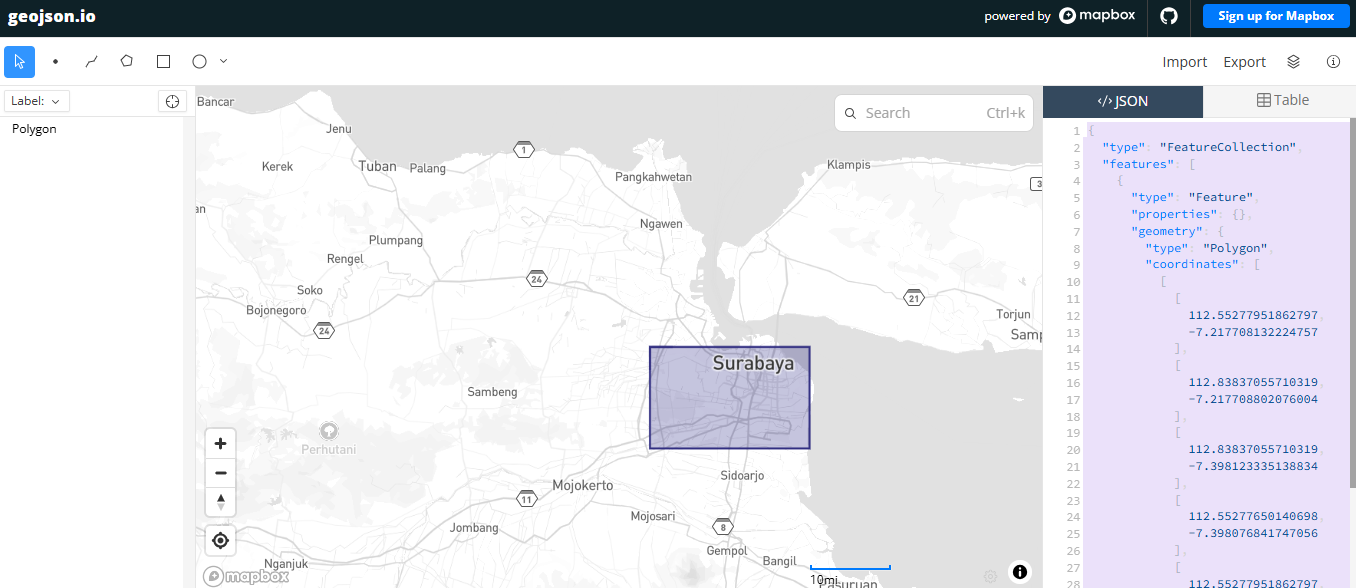

### d. Mengunduh Data NO₂

Setelah proses pengambilan data selesai disusun, data dapat dieksekusi dan diunduh ke dalam format NetCDF (`.nc`) menggunakan kode berikut:


In [79]:
job = s5post.execute_batch(title="NO2 in Surabaya", outputfile="NO2Surabaya.nc")

0:00:00 Job 'j-26060305080543d695f142b353511213': send 'start'
0:00:08 Job 'j-26060305080543d695f142b353511213': created (progress 0%)
0:00:13 Job 'j-26060305080543d695f142b353511213': queued (progress 0%)
0:00:20 Job 'j-26060305080543d695f142b353511213': queued (progress 0%)
0:00:28 Job 'j-26060305080543d695f142b353511213': queued (progress 0%)
0:00:38 Job 'j-26060305080543d695f142b353511213': queued (progress 0%)
0:00:54 Job 'j-26060305080543d695f142b353511213': queued (progress 0%)
0:01:09 Job 'j-26060305080543d695f142b353511213': running (progress N/A)
0:01:29 Job 'j-26060305080543d695f142b353511213': running (progress N/A)
0:01:53 Job 'j-26060305080543d695f142b353511213': running (progress N/A)
0:02:23 Job 'j-26060305080543d695f142b353511213': running (progress N/A)
0:03:01 Job 'j-26060305080543d695f142b353511213': running (progress N/A)
0:03:47 Job 'j-26060305080543d695f142b353511213': running (progress N/A)
0:04:46 Job 'j-26060305080543d695f142b353511213': running (progress N/A)

Ketika proses pengambilan data, aktivitas kalian akan terekam di halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2 . Disitu terdapat nama dataset dan status pengambilan data.

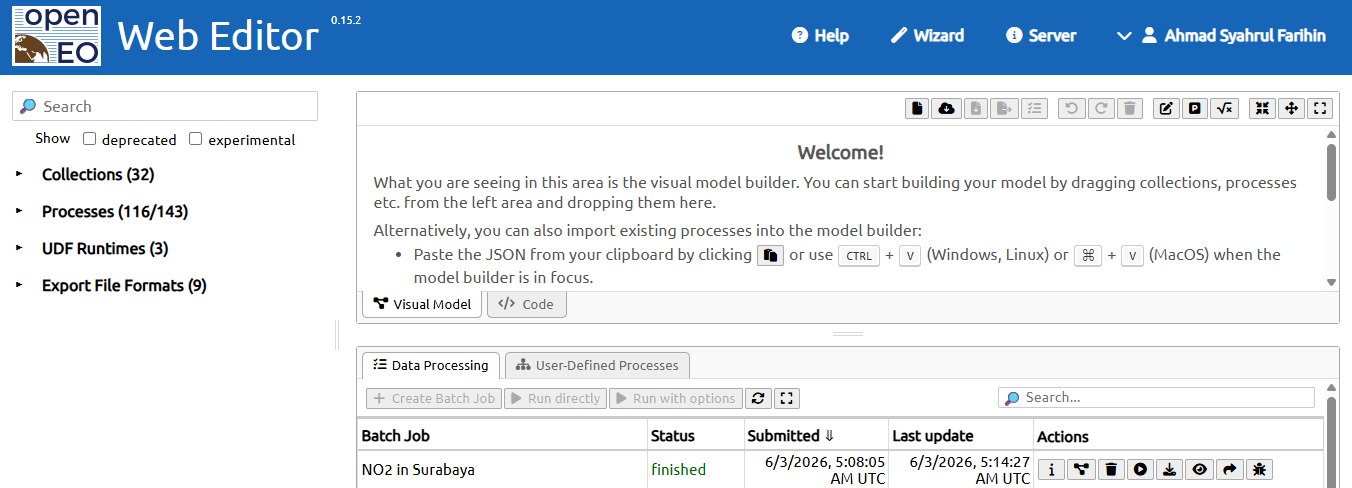

## 2. Preprocessing Data

### a. Install Library NetCDF4

Data hasil unduhan dari Copernicus memiliki format NetCDF (`.nc`), sehingga diperlukan library `netCDF4` untuk membaca dan mengolah data tersebut di Python.


In [80]:
!pip install netCDF4

### b. Membaca File NetCDF

Setelah library `netCDF4` berhasil diinstal, langkah berikutnya adalah membaca file NetCDF yang telah diunduh dari Copernicus. Pada tahap ini, data NO₂ dan informasi waktu diambil dari file untuk mengetahui struktur data yang akan digunakan pada proses selanjutnya.


In [88]:
import netCDF4

file_path = "NO2Surabaya.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2

print(len(no2[0]))
# panjang data per baris

print(len(no2[0][0]))
# panjang data per kolom

print(no2[0][0][0])
# contoh nilai NO2 pertama

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
725
6
6
5.0393337e-05


### c. Menampilkan Contoh Data NO₂

Sebelum melakukan pengolahan data, perlu dilakukan pemeriksaan terhadap isi data NO₂ yang telah dibaca dari file NetCDF. Pada tahap ini ditampilkan beberapa data pertama untuk melihat bentuk data serta mengetahui apakah terdapat nilai yang hilang (*missing value*).


In [89]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[5.0393337005516514e-05 4.44610595877748e-05 2.9139608159312047e-05
  2.689691427804064e-05 2.3220607545226812e-05 1.1937765520997345e-05]
 [3.840621138806455e-05 4.44610595877748e-05 3.189175185980275e-05
  1.1617929885687772e-05 2.3220607545226812e-05 1.2269623766769655e-05]
 [6.721316458424553e-05 6.721316458424553e-05 5.0904414820251986e-05
  2.964823943329975e-05 2.668196611921303e-05 1.2269623766769655e-05]
 [6.792940985178575e-05 5.946733654127456e-05 5.8859281125478446e-05
  2.964823943329975e-05 1.0064916750707198e-05 2.2224347048904747e-05]
 [4.9723927077138796e-05 5.946733654127456e-05 3.00203882943606e-05
  3.725192436832003e-05 1.0064916750707198e-05 1.833280475693755e-05]
 [4.9723927077138796e-05 3.248671055189334e-05 3.00203882943606e-05
  3.725192436832003e-05 2.0999797925469466e-05 1.833280475693755e-05]]
[[6.495301931863651e-05 6.151619891170412e-05 6.151619891170412e-05
  2.4621347620268352e-05 2.4621347620268352e-05 2.294184741913341e-05]
 [6.4

### d. Mengatasi Missing Value dengan Interpolasi Linear

Pada data NO₂ terdapat beberapa nilai yang hilang (*missing value*) yang ditandai dengan simbol `--`. Agar data dapat digunakan pada proses analisis dan pemodelan, nilai yang hilang tersebut diisi menggunakan metode Interpolasi Linear.


In [90]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

### e. Mengubah Format Tanggal dan Menghitung Rata-rata NO₂

Setelah missing value berhasil diatasi, langkah berikutnya adalah mengubah format tanggal menjadi `YYYY-MM-DD` serta menghitung rata-rata nilai NO₂ pada setiap hari. Proses ini dilakukan agar setiap tanggal hanya memiliki satu nilai NO₂ yang mewakili seluruh area penelitian.


In [91]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

### f. Menyimpan Data ke CSV

Setelah data tanggal dan rata-rata NO₂ harian berhasil diperoleh, langkah berikutnya adalah menyimpan data tersebut ke dalam format CSV agar lebih mudah digunakan pada proses analisis dan pemodelan.


In [92]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Surabaya_timeseries.csv", index=False)

### g. Mengecek Missing Value pada Data Harian

Setelah data disimpan ke dalam format CSV, perlu dilakukan pengecekan untuk memastikan bahwa seluruh tanggal pada rentang pengamatan tersedia. Proses ini dilakukan dengan membandingkan tanggal yang ada pada dataset dengan rentang tanggal harian yang seharusnya ada.


In [93]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Surabaya_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)
print(len(df))
print(len(missing_dates))

Jumlah hari missing: 6
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31'],
              dtype='datetime64[ns]', freq=None)
725
6


### h. Mengatasi Missing Date dengan Interpolasi Linear

Apabila ditemukan tanggal yang hilang pada data time series, maka perlu dilakukan pengisian nilai agar data menjadi lengkap dan berurutan. Pada penelitian ini, missing date diatasi menggunakan metode Interpolasi Linear berdasarkan waktu (*time interpolation*).


In [94]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

/tmp/ipykernel_1188/2413223189.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


### i. Verifikasi Hasil Interpolasi

Setelah proses interpolasi selesai dilakukan, perlu dilakukan pengecekan kembali untuk memastikan bahwa seluruh tanggal pada rentang pengamatan sudah tersedia dan tidak ada lagi data yang hilang.


In [95]:
import pandas as pd
import numpy as np

df = pd.read_csv("no2_timeseries_interpolated.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)
print(len(df))
print(len(missing_dates))

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')
731
0


### j. Deteksi Outlier Menggunakan Metode IQR

Setelah data harian lengkap, langkah berikutnya adalah mendeteksi nilai outlier. Pada penelitian ini digunakan metode *Interquartile Range* (IQR), yaitu metode yang mengidentifikasi data yang berada di luar batas bawah (*lower bound*) dan batas atas (*upper bound*) berdasarkan distribusi data.


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 31
         date       NO2
38 2023-11-08  0.000081
46 2023-11-16  0.000093
47 2023-11-17  0.000144
48 2023-11-18  0.000105
56 2023-11-26  0.000089


### k. Visualisasi Hasil Deteksi Outlier

Setelah outlier berhasil dideteksi menggunakan metode IQR, langkah berikutnya adalah menampilkan hasilnya dalam bentuk grafik. Visualisasi ini bertujuan untuk melihat posisi outlier pada data time series NO₂ serta membandingkannya dengan batas bawah dan batas atas yang dihasilkan oleh metode IQR.


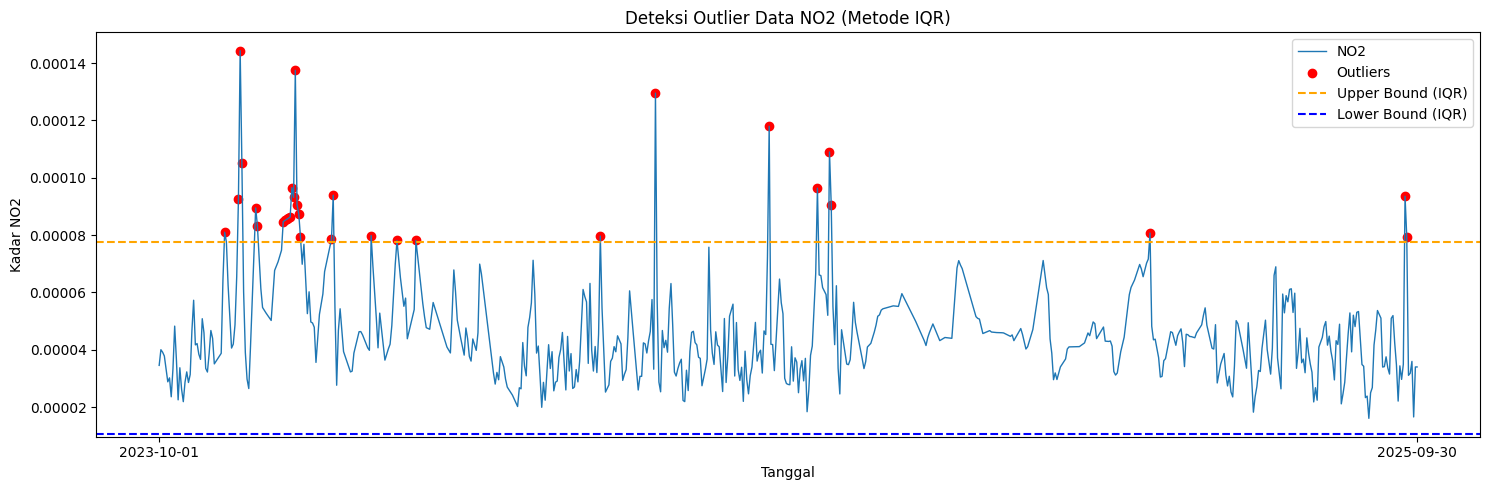

In [97]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

### l. Menghapus Outlier dan Mengisi Kembali Nilai Data

Karena data yang digunakan merupakan data time series, nilai yang terdeteksi sebagai outlier tidak langsung dihapus begitu saja. Outlier terlebih dahulu diubah menjadi nilai kosong (*NaN*), kemudian diisi kembali menggunakan metode Interpolasi Linear agar pola data tetap terjaga.


In [98]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 31
Jumlah missing setelah interpolasi: 0


### m. Visualisasi Data Setelah Penghapusan Outlier

Setelah outlier dihapus dan nilainya digantikan menggunakan interpolasi linear, dilakukan visualisasi kembali untuk melihat hasil pembersihan data. Grafik ini digunakan untuk memastikan bahwa tidak terdapat lonjakan nilai yang tidak wajar serta pola data tetap terjaga.


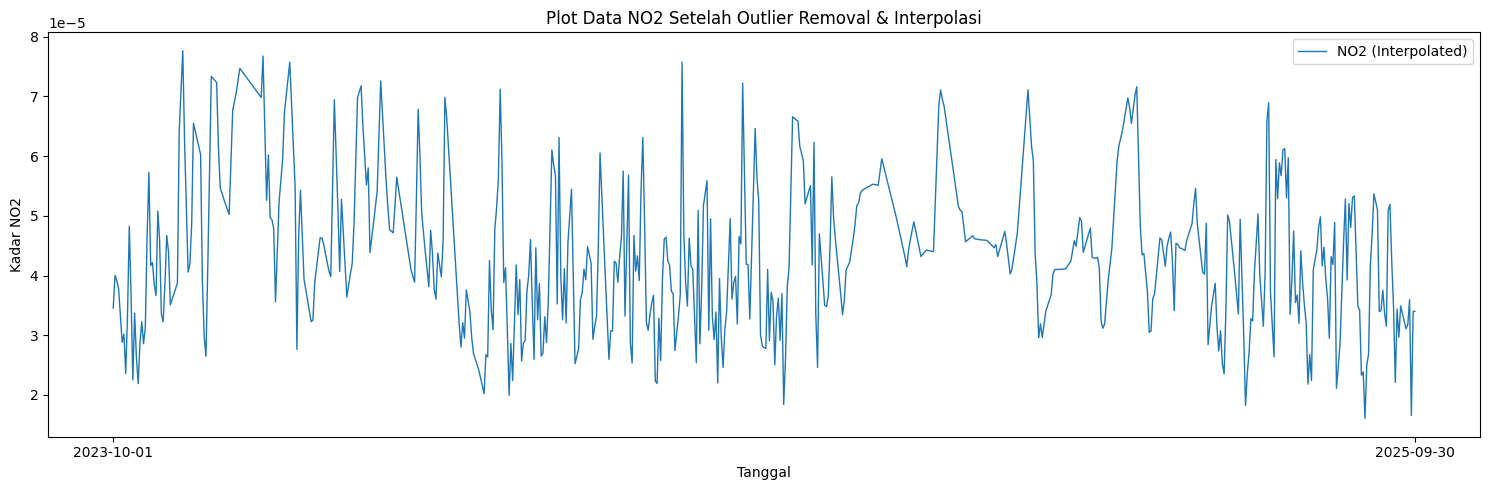

In [99]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Modeling Menggunakan KNN Regression

### a. Normalisasi Data

Sebelum dilakukan proses pemodelan menggunakan KNN Regression, data perlu dinormalisasi terlebih dahulu. Hal ini dilakukan karena algoritma KNN menggunakan perhitungan jarak antar data, sehingga perbedaan skala nilai dapat memengaruhi hasil prediksi. Pada penelitian ini digunakan metode Min-Max Scaling untuk mengubah nilai NO₂ ke rentang 0–1.


In [131]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

### b. Uji Korelasi Antar Lag

Karena data time series hanya memiliki satu variabel utama, maka data perlu diubah terlebih dahulu ke bentuk *supervised learning*. Pada tahap ini dibuat beberapa fitur berdasarkan nilai NO₂ pada hari-hari sebelumnya (*lag*), kemudian dilakukan uji korelasi untuk mengetahui hubungan setiap fitur terhadap nilai target pada hari ke-*t*.


In [132]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-4 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# contoh penggunaan
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.172239
NO2(t-29)    0.175705
NO2(t-28)    0.180947
NO2(t-27)    0.160614
NO2(t-26)    0.149072
NO2(t-25)    0.127998
NO2(t-24)    0.126564
NO2(t-23)    0.146201
NO2(t-22)    0.175737
NO2(t-21)    0.158196
NO2(t-20)    0.121070
NO2(t-19)    0.105504
NO2(t-18)    0.105167
NO2(t-17)    0.100166
NO2(t-16)    0.113034
NO2(t-15)    0.102674
NO2(t-14)    0.096606
NO2(t-13)    0.072637
NO2(t-12)    0.086931
NO2(t-11)    0.129542
NO2(t-10)    0.173475
NO2(t-9)     0.238399
NO2(t-8)     0.267597
NO2(t-7)     0.243643
NO2(t-6)     0.217202
NO2(t-5)     0.221908
NO2(t-4)     0.267720
NO2(t-3)     0.368184
NO2(t-2)     0.514828
NO2(t-1)     0.718353
dtype: float64


### c. Membentuk Dataset Supervised 4 Hari Sebelumnya

Berdasarkan hasil uji korelasi, dipilih empat hari sebelumnya sebagai fitur masukan untuk model. Dataset kemudian diubah menjadi bentuk supervised dengan fitur `NO2(t-4)` hingga `NO2(t-1)` dan target `NO2(t)`.


In [133]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.144044  0.186706  0.179891  0.169546  0.134676
5    0.186706  0.179891  0.169546  0.134676  0.099351
6    0.179891  0.169546  0.134676  0.099351  0.110093
7    0.169546  0.134676  0.099351  0.110093  0.058648
8    0.134676  0.099351  0.110093  0.058648  0.134731
..        ...       ...       ...       ...       ...
726  0.146877  0.604097  0.493871  0.116991  0.122623
727  0.604097  0.493871  0.116991  0.122623  0.154898
728  0.493871  0.116991  0.122623  0.154898  0.003773
729  0.116991  0.122623  0.154898  0.003773  0.139778
730  0.122623  0.154898  0.003773  0.139778  0.139778

[727 rows x 5 columns]
(727, 5)


### d. Membentuk Dataset Supervised 10 Hari Sebelumnya

Selain menggunakan empat hari sebelumnya sebagai fitur, dilakukan juga percobaan dengan sepuluh hari sebelumnya untuk membandingkan performa model. Tujuannya adalah mengetahui apakah penambahan jumlah lag dapat meningkatkan kemampuan prediksi KNN Regression.


In [134]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.144044  0.186706  0.179891  0.169546  0.134676  0.099351  0.110093   
11    0.186706  0.179891  0.169546  0.134676  0.099351  0.110093  0.058648   
12    0.179891  0.169546  0.134676  0.099351  0.110093  0.058648  0.134731   
13    0.169546  0.134676  0.099351  0.110093  0.058648  0.134731  0.250876   
14    0.134676  0.099351  0.110093  0.058648  0.134731  0.250876  0.159848   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.279523  0.205321  0.146261  0.046909  0.142779  0.105931  0.146877   
727   0.205321  0.146261  0.046909  0.142779  0.105931  0.146877  0.604097   
728   0.146261  0.046909  0.142779  0.105931  0.146877  0.604097  0.493871   
729   0.046909  0.142779  0.105931  0.146877  0.604097  0.493871  0.116991   
730   0.142779  0.105931  0.146877  0.604097  0.493871  0.116991  0.122623   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.058648  0.

### e. Modeling dan Evaluasi menggunakan KNN Regression

Pada tahap ini digunakan KNN Regression untuk memprediksi NO
2
	​

(t) berdasarkan nilai beberapa hari sebelumnya. Data dibagi menjadi data latih dan data uji (80:20) tanpa shuffle agar urutan time series tetap terjaga. Evaluasi model dilakukan menggunakan RMSE, R² Score, dan MAPE untuk mengukur performa prediksi pada beberapa variasi lag (4 dan 10 hari sebelumnya).

In [135]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 581 — Test Size: 146
RMSE: 0.080164
R² Score: 0.2134
MAPE: 77.9955%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 576 — Test Size: 145
RMSE: 0.089126
R² Score: 0.0344
MAPE: 78.3079%


### f. Hasil Prediksi KNN Regression

Pada tahap ini dilakukan prediksi menggunakan model KNN Regression dengan variasi jumlah lag (4, 10, dan 30 hari sebelumnya).

In [136]:
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")


=== KNN - 30 Hari Sebelumnya ===
Train Size: 560 — Test Size: 141
RMSE: 0.103285
R² Score: -0.2661
MAPE: 109.8531%


### g. Visualisasi Hasil Prediksi KNN (4 Hari Sebelumnya)

Pada tahap ini dilakukan visualisasi hasil prediksi model KNN Regression dengan menggunakan 4 hari sebelumnya sebagai fitur. Grafik digunakan untuk membandingkan nilai aktual dan nilai prediksi sehingga dapat dilihat seberapa baik model mengikuti pola data.

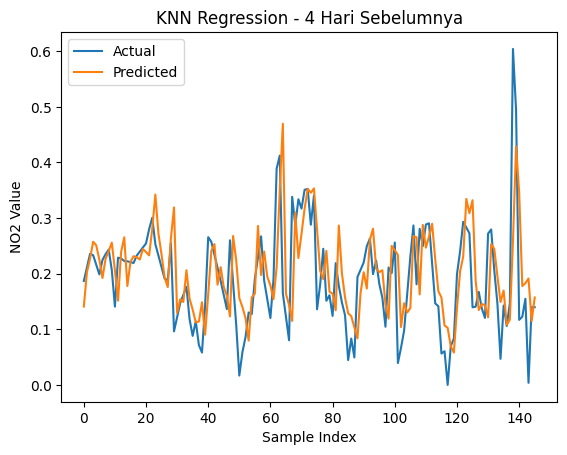

In [137]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### h. Visualisasi Hasil Prediksi KNN (4 Hari Sebelumnya)

Pada tahap ini dilakukan visualisasi hasil prediksi model KNN Regression dengan menggunakan 10 hari sebelumnya sebagai fitur. Grafik digunakan untuk membandingkan nilai aktual dan nilai prediksi sehingga dapat dilihat seberapa baik model mengikuti pola data.

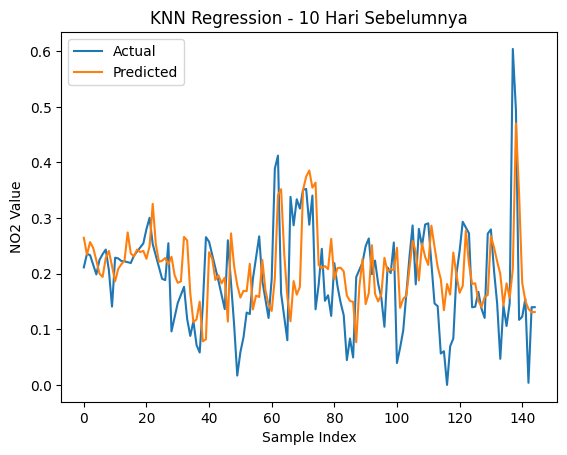

In [138]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### i. Visualisasi Hasil Prediksi KNN (4 Hari Sebelumnya)

Pada tahap ini dilakukan visualisasi hasil prediksi model KNN Regression dengan menggunakan 30 hari sebelumnya sebagai fitur. Grafik digunakan untuk membandingkan nilai aktual dan nilai prediksi sehingga dapat dilihat seberapa baik model mengikuti pola data.

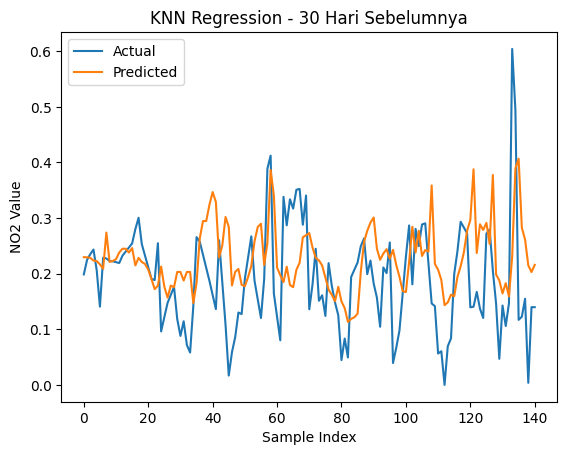

In [140]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

## Kesimpulan

Berdasarkan hasil penelitian ini, data NO₂ harian di wilayah Surabaya berhasil diolah dari data satelit Sentinel-5P menjadi bentuk time series yang bersih melalui proses preprocessing seperti interpolasi, penanganan outlier, dan normalisasi data. Model KNN Regression kemudian digunakan dengan pendekatan supervised learning menggunakan beberapa variasi lag (4, 10, dan 30 hari sebelumnya) untuk memprediksi nilai NO₂ harian. Hasil pengujian menunjukkan bahwa model mampu mengikuti pola perubahan data, namun performanya sangat dipengaruhi oleh jumlah lag yang digunakan serta karakteristik data time series yang fluktuatif. Pendekatan ini membuktikan bahwa KNN Regression dapat digunakan untuk peramalan sederhana kualitas udara, meskipun masih dapat ditingkatkan dengan metode yang lebih kompleks untuk hasil yang lebih akurat.
